## 1. Setup and Imports

In [19]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
from src.data_loading import (
    load_wind_dataset, extract_node_metadata, get_column_groups,
    handle_missing_values, split_data_chronological
)
from src.graph_building import build_heterogeneous_graph, print_graph_statistics
from src.baselines import PersistenceModel, LSTMBaseline, GraphConvLSTM, STGATBaseline
from src.training import create_dataloaders, train_model
from src.evaluation import (
    evaluate_model, compute_metrics, compute_metrics_per_horizon,
    plot_training_history, plot_predictions, plot_scatter,
    plot_metrics_per_horizon, compare_models, save_results
)

print("All modules imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All modules imported successfully!
PyTorch version: 2.6.0+cpu
CUDA available: False


## 2. Load and Prepare Data

In [4]:
# Load dataset
data_path = Path('../data/raw/Wind Spatio-Temporal Dataset2.csv')
coords_df, timeseries_df = load_wind_dataset(data_path)

print(f"Loaded {len(timeseries_df)} timestamps")
print(f"Date range: {timeseries_df['Time'].min()} to {timeseries_df['Time'].max()}")

Loaded 8760 timestamps
Date range: 2010-09-01 00:00:00 to 2011-08-31 22:59:00


In [5]:
# Extract metadata
metadata = extract_node_metadata(coords_df)
print(f"Number of nodes: {len(metadata)}")
print(f"Turbines: {(metadata['node_type'] == 'turbine').sum()}")
print(f"Masts: {(metadata['node_type'] == 'mast').sum()}")

metadata.head()

Number of nodes: 203
Turbines: 200
Masts: 3


,node_id,node_name,node_type,latitude,longitude
0,0,Turbine1,turbine,40.477244,-88.798072
1,1,Turbine2,turbine,40.475753,-88.795484
2,2,Turbine3,turbine,40.482172,-88.779434
3,3,Turbine4,turbine,40.476083,-88.779391
4,4,Turbine5,turbine,40.477691,-88.772025


In [6]:
# Get column groups
col_groups = get_column_groups(timeseries_df)

# Focus on turbine power (200 turbines)
power_cols = col_groups['turbine_power'][:200]
print(f"Selected {len(power_cols)} turbine power columns")

# Handle missing values
timeseries_df = handle_missing_values(timeseries_df, power_cols, method='forward_fill')
print("Missing values handled")

Selected 200 turbine power columns
Missing values handled


In [7]:
# Split data chronologically (60/20/20)
train_df, val_df, test_df = split_data_chronological(timeseries_df, train_ratio=0.6, val_ratio=0.2)

print(f"Train: {len(train_df)} samples ({train_df['Time'].min()} to {train_df['Time'].max()})")
print(f"Val: {len(val_df)} samples ({val_df['Time'].min()} to {val_df['Time'].max()})")
print(f"Test: {len(test_df)} samples ({test_df['Time'].min()} to {test_df['Time'].max()})")

Train: 5256 samples (2010-09-01 00:00:00 to 2011-04-07 22:59:00)
Val: 1752 samples (2011-04-07 23:59:00 to 2011-06-19 22:59:00)
Test: 1752 samples (2011-06-19 23:59:00 to 2011-08-31 22:59:00)


## 3. Build Graph Structure

In [8]:
# Filter metadata to match power columns (turbines only)
metadata_turbines = metadata[metadata['node_type'] == 'turbine'].iloc[:200].reset_index(drop=True)

# Graph building configuration
graph_config = {
    'spatial_k': 8,
    'wake_angle': 30.0,
    'wake_max_dist': 5.0,
    'corr_threshold': 0.75,
    'corr_max_edges': 15
}

# Compute mean wind direction
wind_dir = timeseries_df['Mast1_Direction'].mean()
print(f"Mean wind direction: {wind_dir:.1f}°")

# Build heterogeneous graph
graph = build_heterogeneous_graph(
    metadata_turbines,
    train_df,  # Use training data for correlation edges
    power_cols,
    wind_dir,
    graph_config
)

print_graph_statistics(graph)

Mean wind direction: 203.4°
HETEROGENEOUS GRAPH STATISTICS

Number of nodes: 200

SPATIAL EDGES:
  Total edges: 1600
  Average degree: 8.00

WAKE EDGES:
  Total edges: 1780
  Average degree: 8.90

CORRELATION EDGES:
  Total edges: 2768
  Average degree: 13.84
HETEROGENEOUS GRAPH STATISTICS

Number of nodes: 200

SPATIAL EDGES:
  Total edges: 1600
  Average degree: 8.00

WAKE EDGES:
  Total edges: 1780
  Average degree: 8.90

CORRELATION EDGES:
  Total edges: 2768
  Average degree: 13.84


In [9]:
# Convert edges to PyTorch tensors
edge_indices = {
    'spatial': torch.LongTensor(graph['spatial']['edge_index']),
    'wake': torch.LongTensor(graph['wake']['edge_index']),
    'correlation': torch.LongTensor(graph['correlation']['edge_index'])
}

edge_weights = {
    'spatial': torch.FloatTensor(graph['spatial']['edge_weight']),
    'wake': torch.FloatTensor(graph['wake']['edge_weight']),
    'correlation': torch.FloatTensor(graph['correlation']['edge_weight'])
}

print("Graph edges converted to tensors")

Graph edges converted to tensors


## 4. Create DataLoaders

In [10]:
# Configuration
INPUT_WINDOW = 24  # 24 hours
FORECAST_HORIZON = 6  # 6 hours ahead
BATCH_SIZE = 16

# Create dataloaders
train_loader, val_loader, test_loader = create_dataloaders(
    train_df, val_df, test_df,
    node_cols=power_cols,
    input_window=INPUT_WINDOW,
    forecast_horizon=FORECAST_HORIZON,
    batch_size=BATCH_SIZE
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Check data shape
x_sample, y_sample = next(iter(train_loader))
print(f"\nInput shape: {x_sample.shape}  (batch, nodes, window, features)")
print(f"Target shape: {y_sample.shape}  (batch, nodes, horizon)")

Train batches: 327
Val batches: 108
Test batches: 108

Input shape: torch.Size([16, 200, 24, 1])  (batch, nodes, window, features)
Target shape: torch.Size([16, 200, 6])  (batch, nodes, horizon)

Input shape: torch.Size([16, 200, 24, 1])  (batch, nodes, window, features)
Target shape: torch.Size([16, 200, 6])  (batch, nodes, horizon)


## 5. Train Baseline Models

### 5.1 Persistence (Naive) Model

In [11]:
# Persistence model (no training needed)
persistence_model = PersistenceModel(forecast_horizon=FORECAST_HORIZON)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Evaluate
y_true_pers, y_pred_pers = evaluate_model(
    persistence_model, test_loader, device, use_graph=False
)

metrics_pers = compute_metrics(y_true_pers, y_pred_pers)
print("\nPersistence Model Results:")
for metric, value in metrics_pers.items():
    print(f"  {metric}: {value:.4f}")

Using device: cpu


Evaluating: 100%|██████████| 108/108 [00:06<00:00, 17.23it/s]



Persistence Model Results:
  MAE: 0.1036
  RMSE: 0.1713
  MAPE: 416.4942
  R2: 0.3525
  NRMSE: 0.9238


### 5.2 LSTM Baseline

In [12]:
# Initialize LSTM model
lstm_model = LSTMBaseline(
    input_features=1,  # Only power
    hidden_dim=64,
    num_layers=2,
    forecast_horizon=FORECAST_HORIZON,
    dropout=0.1
)

print(f"LSTM parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

LSTM parameters: 50,822


In [13]:
# Training configuration
train_config = {
    'device': device,
    'num_epochs': 50,
    'lr': 0.001,
    'weight_decay': 1e-5,
    'scheduler_patience': 5,
    'early_stopping_patience': 15
}

# Train LSTM
history_lstm = train_model(
    lstm_model,
    train_loader,
    val_loader,
    train_config,
    checkpoint_dir=Path('../checkpoints/lstm')
)

Training on device: cpu
Model: LSTMBaseline
Number of parameters: 50,822
Using graph structure: False

Epoch 1/50


Validating: 100%|██████████| 108/108 [00:21<00:00,  5.05it/s]



Train Loss: 0.0770 | Val Loss: 0.0594 | LR: 1.00e-03
✓ Best model saved (val_loss: 0.0594)

Epoch 2/50


Validating: 100%|██████████| 108/108 [00:22<00:00,  4.89it/s]


Train Loss: 0.0542 | Val Loss: 0.0576 | LR: 1.00e-03
✓ Best model saved (val_loss: 0.0576)

Epoch 3/50


...

Train Loss: 0.0498 | Val Loss: 0.0581 | LR: 1.25e-04

Epoch 29/50


Validating: 100%|██████████| 108/108 [00:22<00:00,  4.88it/s]


Train Loss: 0.0498 | Val Loss: 0.0578 | LR: 1.25e-04

Epoch 30/50


Validating: 100%|██████████| 108/108 [00:21<00:00,  5.05it/s]

Train Loss: 0.0498 | Val Loss: 0.0577 | LR: 1.25e-04

Early stopping triggered after 30 epochs

Training complete! Best val loss: 0.0568
Checkpoints saved to: ..\checkpoints\lstm


Saved training history plot to ..\results\lstm_training_history.png


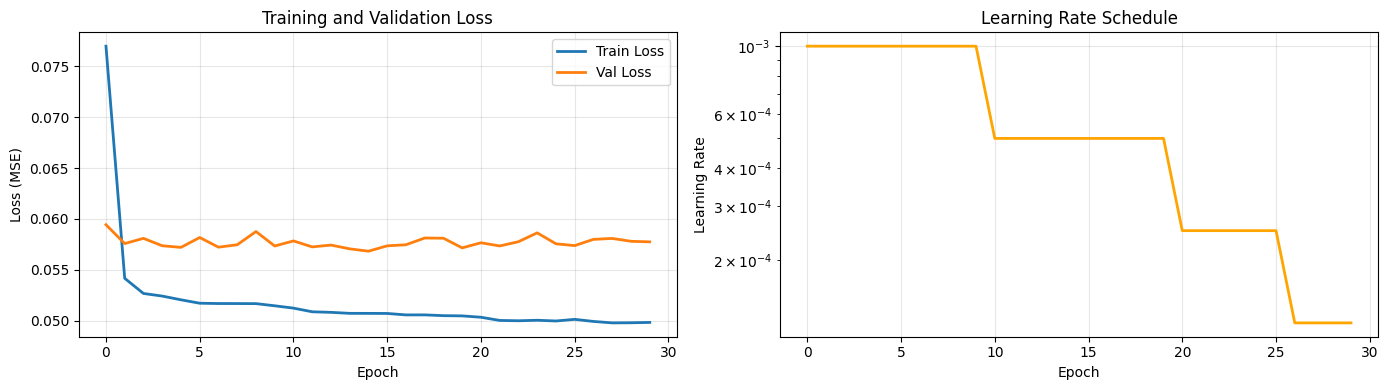

In [14]:
# Plot training history
plot_training_history(history_lstm, save_path=Path('../results/lstm_training_history.png'))

In [15]:
# Load best model and evaluate
from src.training import load_checkpoint

lstm_model = load_checkpoint(
    lstm_model,
    Path('../checkpoints/lstm/LSTMBaseline_best.pth'),
    device
)

y_true_lstm, y_pred_lstm = evaluate_model(
    lstm_model, test_loader, device, use_graph=False
)

metrics_lstm = compute_metrics(y_true_lstm, y_pred_lstm)
print("\nLSTM Model Results:")
for metric, value in metrics_lstm.items():
    print(f"  {metric}: {value:.4f}")

Loaded checkpoint from epoch 14
Validation loss: 0.0568


Evaluating: 100%|██████████| 108/108 [00:20<00:00,  5.36it/s]




LSTM Model Results:
  MAE: 0.1336
  RMSE: 0.1710
  MAPE: 1391.4211
  R2: 0.3551
  NRMSE: 0.9220


### 5.3 GCN-LSTM Model

In [24]:
# Initialize GCN-LSTM model (recreate with fixed class)
gcn_lstm_model = GraphConvLSTM(
    input_features=1,
    hidden_dim=64,
    num_graph_layers=2,
    forecast_horizon=FORECAST_HORIZON,
    dropout=0.1
)

print(f"GCN-LSTM parameters: {sum(p.numel() for p in gcn_lstm_model.parameters()):,}")

GCN-LSTM parameters: 44,006


In [30]:
# Reload modules to get latest fixes
import importlib
import src.baselines
importlib.reload(src.baselines)
from src.baselines import GraphConvLSTM, STGATBaseline

print("Modules reloaded successfully!")

Modules reloaded successfully!


In [25]:
# Use spatial edges for GCN-LSTM
spatial_edge_index = edge_indices['spatial']

# Train GCN-LSTM
history_gcn_lstm = train_model(
    gcn_lstm_model,
    train_loader,
    val_loader,
    train_config,
    edge_indices={'spatial': spatial_edge_index},
    checkpoint_dir=Path('../checkpoints/gcn_lstm')
)

Training on device: cpu
Model: GraphConvLSTM
Number of parameters: 44,006
Using graph structure: True

Epoch 1/50


Validating: 100%|██████████| 108/108 [01:36<00:00,  1.12it/s]


Train Loss: 0.0704 | Val Loss: 0.0560 | LR: 1.00e-03
✓ Best model saved (val_loss: 0.0560)

Epoch 2/50


Validating: 100%|██████████| 108/108 [01:38<00:00,  1.10it/s]


Train Loss: 0.0554 | Val Loss: 0.0570 | LR: 1.00e-03

Epoch 3/50


...

Train Loss: 0.0497 | Val Loss: 0.0582 | LR: 1.25e-04

Epoch 22/50


Validating: 100%|██████████| 108/108 [01:00<00:00,  1.77it/s]


Train Loss: 0.0495 | Val Loss: 0.0583 | LR: 1.25e-04

Epoch 23/50


Validating: 100%|██████████| 108/108 [01:00<00:00,  1.77it/s]

Train Loss: 0.0495 | Val Loss: 0.0570 | LR: 1.25e-04

Early stopping triggered after 23 epochs

Training complete! Best val loss: 0.0558
Checkpoints saved to: ..\checkpoints\gcn_lstm


In [27]:
# Evaluate GCN-LSTM
gcn_lstm_model = load_checkpoint(
    gcn_lstm_model,
    Path('../checkpoints/gcn_lstm/GraphConvLSTM_best.pth'),
    device
)

y_true_gcn, y_pred_gcn = evaluate_model(
    gcn_lstm_model, test_loader, device,
    edge_indices={'spatial': spatial_edge_index},
    use_graph=True
)

metrics_gcn_lstm = compute_metrics(y_true_gcn, y_pred_gcn)
print("\nGCN-LSTM Model Results:")
for metric, value in metrics_gcn_lstm.items():
    print(f"  {metric}: {value:.4f}")

Loaded checkpoint from epoch 7
Validation loss: 0.0558


Evaluating: 100%|██████████| 108/108 [01:41<00:00,  1.06it/s]


GCN-LSTM Model Results:
  MAE: 0.1318
  RMSE: 0.1701
  MAPE: 1452.7908
  R2: 0.3615
  NRMSE: 0.9174


### 5.4 ST-GAT Model

In [31]:
# Initialize ST-GAT model
stgat_model = STGATBaseline(
    input_features=1,
    hidden_dim=64,
    num_heads=4,
    num_layers=2,
    forecast_horizon=FORECAST_HORIZON,
    dropout=0.1
)

print(f"ST-GAT parameters: {sum(p.numel() for p in stgat_model.parameters()):,}")

ST-GAT parameters: 52,326


In [32]:
# Train ST-GAT
history_stgat = train_model(
    stgat_model,
    train_loader,
    val_loader,
    train_config,
    edge_indices={'spatial': spatial_edge_index},
    checkpoint_dir=Path('../checkpoints/stgat')
)

Training on device: cpu
Model: STGATBaseline
Number of parameters: 52,326
Using graph structure: False

Epoch 1/50


Validating: 100%|██████████| 108/108 [00:18<00:00,  5.89it/s]



Train Loss: 0.0618 | Val Loss: 0.0569 | LR: 1.00e-03
✓ Best model saved (val_loss: 0.0569)

Epoch 2/50


Validating: 100%|██████████| 108/108 [00:23<00:00,  4.69it/s]



Train Loss: 0.0553 | Val Loss: 0.0565 | LR: 1.00e-03
✓ Best model saved (val_loss: 0.0565)

Epoch 3/50


...

Train Loss: 0.0519 | Val Loss: 0.0566 | LR: 6.25e-05

Epoch 29/50


Validating: 100%|██████████| 108/108 [00:13<00:00,  8.20it/s]


Train Loss: 0.0519 | Val Loss: 0.0565 | LR: 6.25e-05

Epoch 30/50


Validating: 100%|██████████| 108/108 [00:14<00:00,  7.35it/s]

Train Loss: 0.0519 | Val Loss: 0.0568 | LR: 6.25e-05

Early stopping triggered after 30 epochs

Training complete! Best val loss: 0.0564
Checkpoints saved to: ..\checkpoints\stgat


In [33]:
# Evaluate ST-GAT
stgat_model = load_checkpoint(
    stgat_model,
    Path('../checkpoints/stgat/STGATBaseline_best.pth'),
    device
)

y_true_stgat, y_pred_stgat = evaluate_model(
    stgat_model, test_loader, device,
    edge_indices={'spatial': spatial_edge_index},
    use_graph=True
)

metrics_stgat = compute_metrics(y_true_stgat, y_pred_stgat)
print("\nST-GAT Model Results:")
for metric, value in metrics_stgat.items():
    print(f"  {metric}: {value:.4f}")

Loaded checkpoint from epoch 14
Validation loss: 0.0564


Evaluating: 100%|██████████| 108/108 [00:15<00:00,  7.16it/s]


ST-GAT Model Results:
  MAE: 0.1267
  RMSE: 0.1662
  MAPE: 1283.9409
  R2: 0.3906
  NRMSE: 0.8962


## 6. Compare All Baseline Models

In [34]:
# Compile results
all_results = {
    'Persistence': metrics_pers,
    'LSTM': metrics_lstm,
    'GCN-LSTM': metrics_gcn_lstm,
    'ST-GAT': metrics_stgat
}

# Create comparison dataframe
results_df = pd.DataFrame(all_results).T
print("\n" + "="*60)
print("BASELINE MODELS COMPARISON")
print("="*60)
print(results_df.to_string())
print("="*60)


BASELINE MODELS COMPARISON
                  MAE      RMSE         MAPE        R2     NRMSE
Persistence  0.103612  0.171303   416.494171  0.352489  0.923833
LSTM         0.133597  0.170958  1391.421143  0.355093  0.921974
GCN-LSTM     0.131819  0.170112  1452.790771  0.361461  0.917410
ST-GAT       0.126695  0.166183  1283.940918  0.390620  0.896219


Saved comparison plot to ..\results\baseline_comparison.png


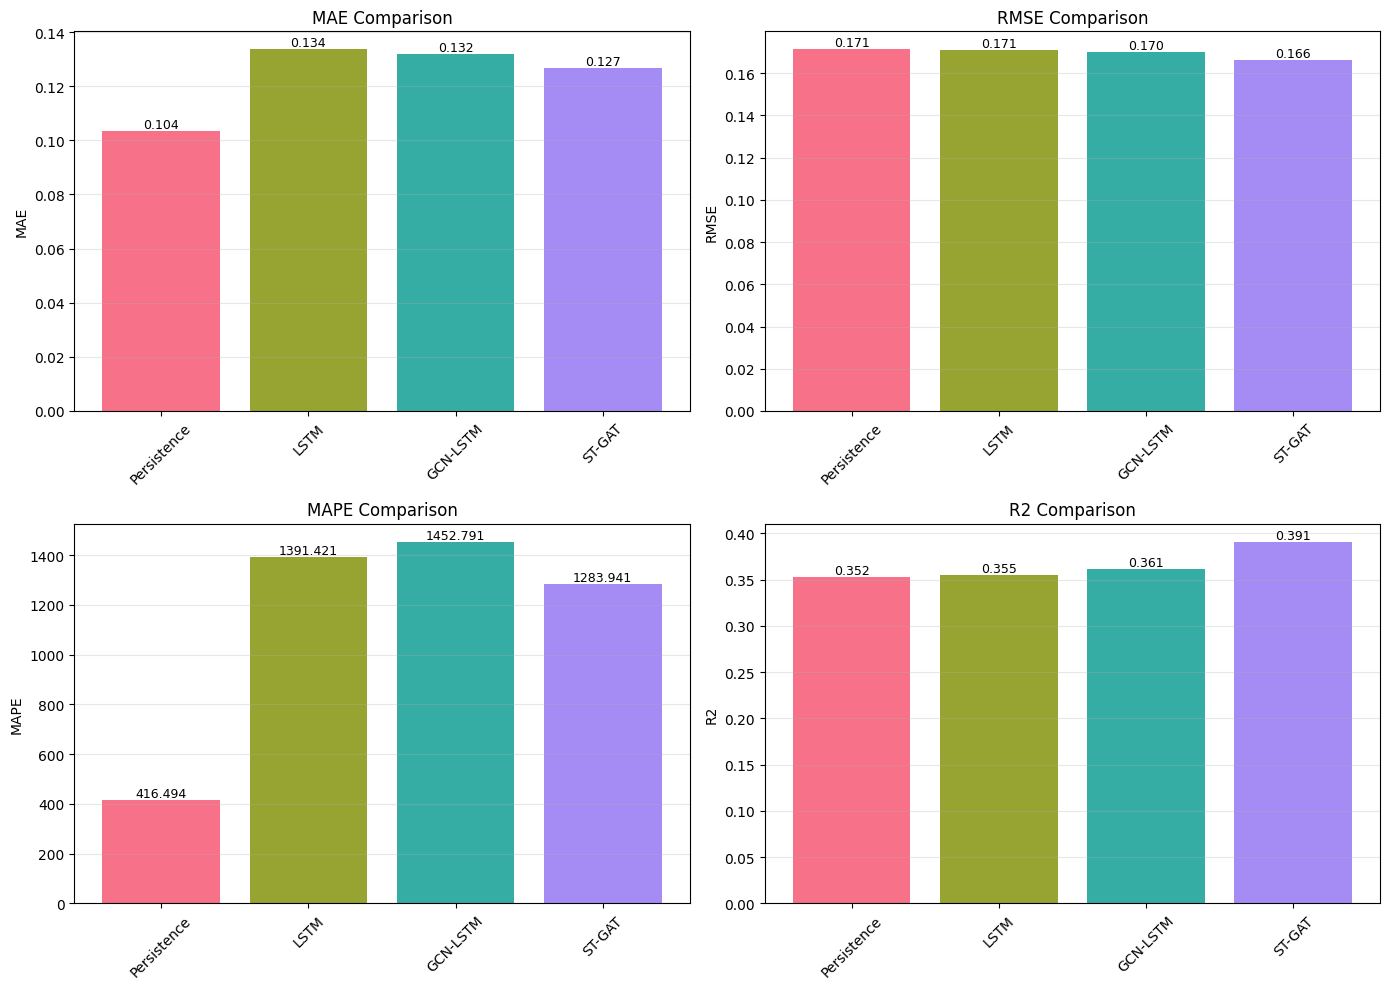

In [35]:
# Plot comparison
compare_models(all_results, save_path=Path('../results/baseline_comparison.png'))

## 7. Detailed Analysis

### 7.1 Metrics Per Forecast Horizon

In [36]:
# Compute metrics for each horizon (using best model: ST-GAT)
metrics_per_horizon = compute_metrics_per_horizon(y_true_stgat, y_pred_stgat)
print("\nMetrics per Forecast Horizon (ST-GAT):")
print(metrics_per_horizon.to_string(index=False))


Metrics per Forecast Horizon (ST-GAT):
     MAE     RMSE        MAPE       R2    NRMSE  horizon
0.073268 0.113970  474.698914 0.713402 0.613655        1
0.102712 0.144136  841.202087 0.541470 0.776699        2
0.123059 0.162529 1170.381226 0.417085 0.876325        3
0.138764 0.175313 1448.655518 0.321901 0.945639        4
0.154279 0.187528 1744.852783 0.224173 1.012098        5
0.168084 0.199044 2023.859253 0.125730 1.075238        6


Saved metrics plot to ..\results\metrics_per_horizon.png


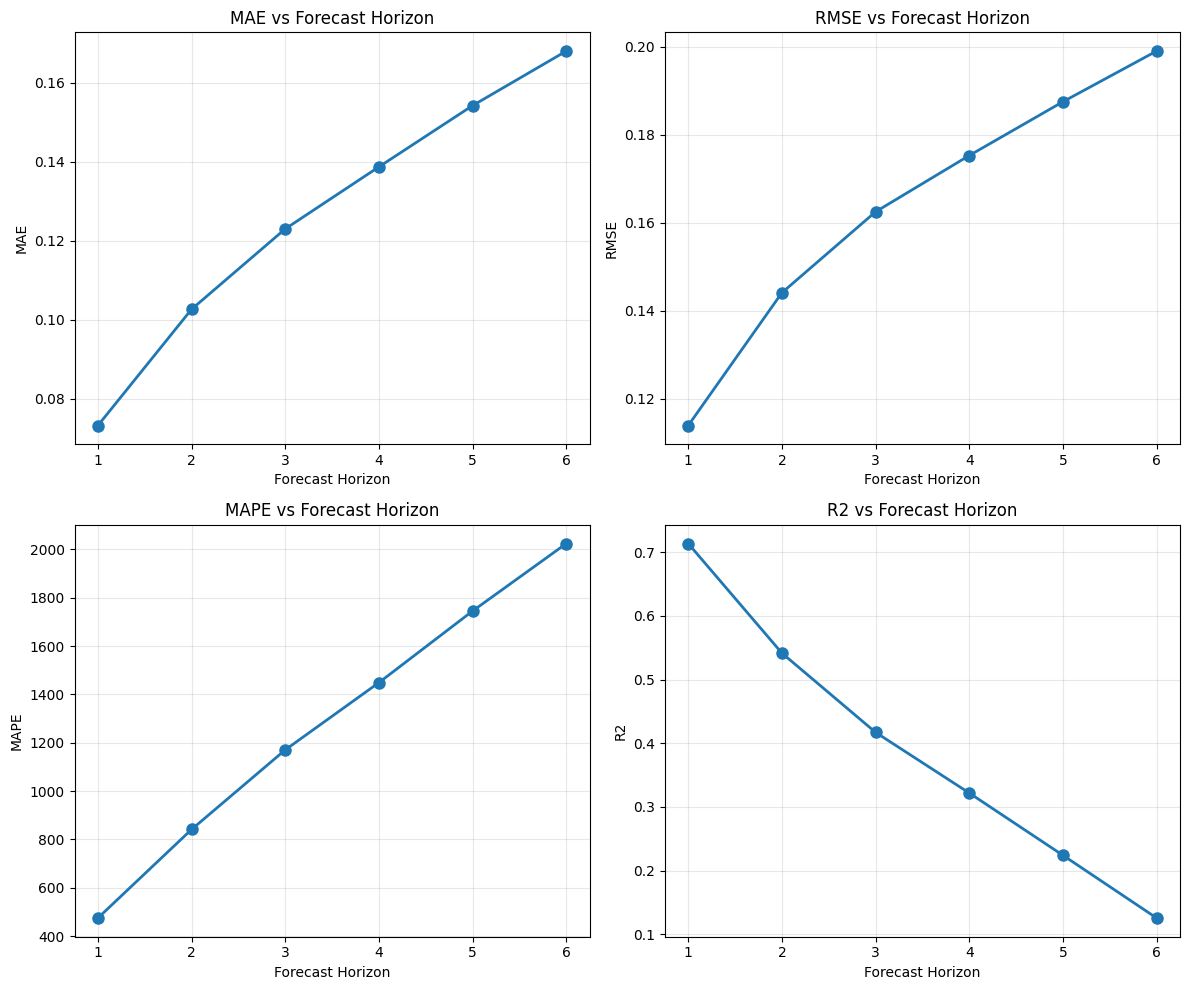

In [37]:
# Plot metrics per horizon
plot_metrics_per_horizon(metrics_per_horizon, save_path=Path('../results/metrics_per_horizon.png'))

### 7.2 Prediction Visualizations

Saved predictions plot to ..\results\stgat_predictions_turbine0.png


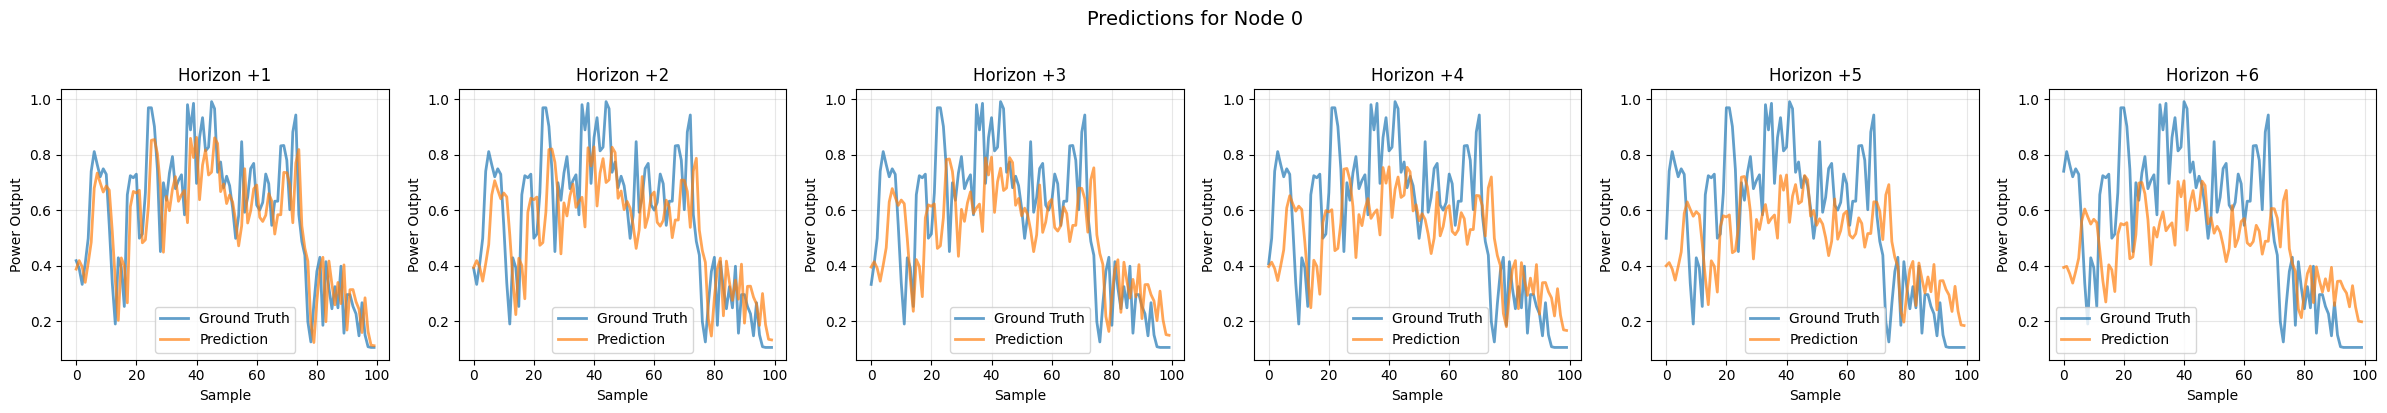

In [38]:
# Plot predictions for a specific turbine
plot_predictions(
    y_true_stgat, y_pred_stgat,
    node_idx=0,
    num_samples=100,
    save_path=Path('../results/stgat_predictions_turbine0.png')
)

Saved scatter plot to ..\results\stgat_scatter.png


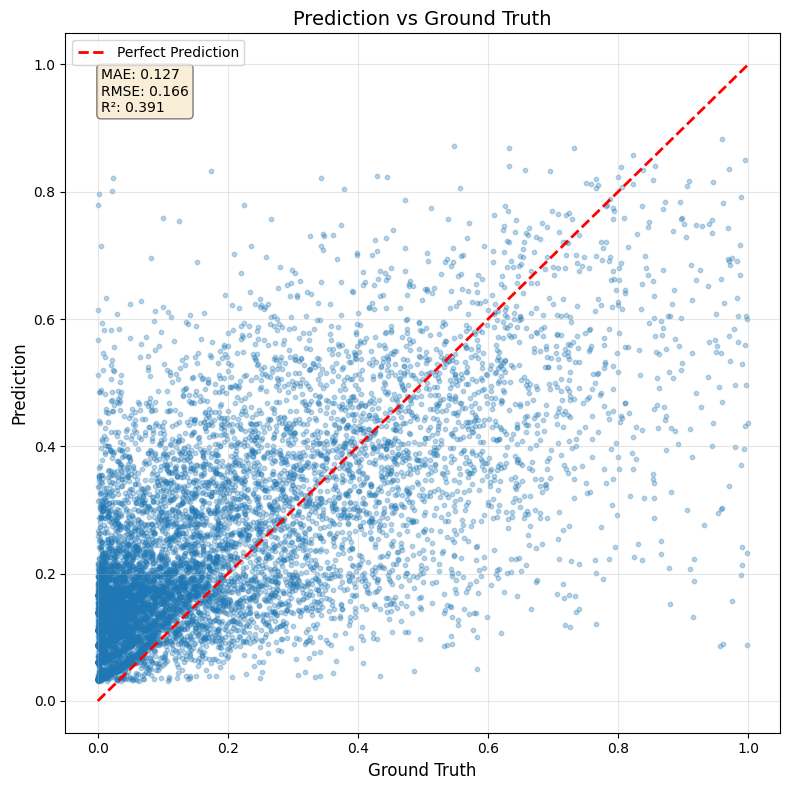

In [39]:
# Scatter plot
plot_scatter(y_true_stgat, y_pred_stgat, save_path=Path('../results/stgat_scatter.png'))

## 8. Save Results

In [41]:
# Reload evaluation module to get the fix
import importlib
import src.evaluation
importlib.reload(src.evaluation)
from src.evaluation import save_results

In [42]:
# Save all results
results_dir = Path('../results/baselines')

for model_name in ['Persistence', 'LSTM', 'GCN-LSTM', 'ST-GAT']:
    if model_name == 'Persistence':
        y_true, y_pred = y_true_pers, y_pred_pers
    elif model_name == 'LSTM':
        y_true, y_pred = y_true_lstm, y_pred_lstm
    elif model_name == 'GCN-LSTM':
        y_true, y_pred = y_true_gcn, y_pred_gcn
    else:
        y_true, y_pred = y_true_stgat, y_pred_stgat
    
    save_results(
        model_name,
        all_results[model_name],
        y_true,
        y_pred,
        results_dir
    )

print("\nAll baseline results saved!")

Results saved to ..\results\baselines
Metrics: ..\results\baselines\Persistence_metrics.json
Results saved to ..\results\baselines
Metrics: ..\results\baselines\LSTM_metrics.json
Results saved to ..\results\baselines
Metrics: ..\results\baselines\LSTM_metrics.json
Results saved to ..\results\baselines
Metrics: ..\results\baselines\GCN-LSTM_metrics.json
Results saved to ..\results\baselines
Metrics: ..\results\baselines\GCN-LSTM_metrics.json
Results saved to ..\results\baselines
Metrics: ..\results\baselines\ST-GAT_metrics.json

All baseline results saved!
Results saved to ..\results\baselines
Metrics: ..\results\baselines\ST-GAT_metrics.json

All baseline results saved!


## Summary

In this notebook, we:
1. ✅ Loaded and prepared the wind farm dataset
2. ✅ Built heterogeneous graph structure with spatial, wake, and correlation edges
3. ✅ Trained four baseline models: Persistence, LSTM, GCN-LSTM, and ST-GAT
4. ✅ Evaluated all models on the test set
5. ✅ Compared performance across metrics (MAE, RMSE, MAPE, R²)
6. ✅ Analyzed results per forecast horizon
7. ✅ Generated visualizations and saved results

**Next Steps:**
- Proceed to `03_hg_kan_experiments.ipynb` to train the Heterogeneous Graph-KAN model
- Compare HG-KAN performance against these baselines
- Conduct ablation studies on KAN components